# Gaussian Barycenter Comparison (Back-and-Forth vs PDLP)

This notebook compares barycenters computed by the back-and-forth solver and the PDLP (raPDHG) solver
on the same set of 2D Gaussian measures.

Note: The PDLP solver uses a dense cost matrix, so the grid size is kept small.


In [1]:
import sys, os
from jax import config

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
config.update('jax_enable_x64', True)
sys.path.insert(0, os.path.abspath(os.path.join('..')))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from uot.data.measure import PointCloudMeasure
from uot.utils.generator_helpers.get_axes import get_axes
from uot.utils.costs import cost_euclid_squared
from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd
from uot.solvers.pdlp_barycenter import PDLPBarycenterSolver


In [2]:
grid_size = 32
axes = get_axes(dim=2, borders=(0.0, 1.0), n_points=grid_size, cell_discretization='cell-centered')
X, Y = np.meshgrid(axes[0], axes[1], indexing='ij')

def normalize_field(field, eps=1e-12):
    field = np.clip(field.astype(np.float64), 0.0, None)
    total = field.sum()
    return field / total if total > eps else field

def gaussian_2d(x, y, mean, cov):
    mu = np.asarray(mean, dtype=np.float64)
    cov = np.asarray(cov, dtype=np.float64)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    dx = np.stack([x - mu[0], y - mu[1]], axis=-1)
    quad = np.einsum('...i,ij,...j->...', dx, inv, dx)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    return norm * np.exp(-0.5 * quad)


In [3]:
means = [
    (0.25, 0.25),
    (0.75, 0.30),
    (0.50, 0.75),
]
covs = [
    [[0.010, 0.000], [0.000, 0.015]],
    [[0.020, 0.006], [0.006, 0.010]],
    [[0.012, 0.000], [0.000, 0.020]],
]

gaussian_fields = []
for mean, cov in zip(means, covs):
    field = gaussian_2d(X, Y, mean, cov)
    gaussian_fields.append(normalize_field(field))

shape_fields = {
    f'Gaussian {i+1}': field for i, field in enumerate(gaussian_fields)
}


In [4]:
measures_weights = [jnp.asarray(field) for field in gaussian_fields]
axes_jax = [jnp.asarray(ax) for ax in axes]

bf_barycenter, bf_diag = backnforth_barycenter_sqeuclidean_nd(
    weights=[1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0],
    measures_weights=measures_weights,
    coordinates=axes_jax,
    outer_maxiter=10,
    stopping_tol=2e-4,
    relaxation=1.0,
    transport_stepsize=1.0,
    transport_maxiter=500,
    transport_tol=1e-4,
)

bf_barycenter = np.asarray(bf_barycenter)
print(f"Back-and-forth iterations: {bf_diag['iterations']}")
print(f"Back-and-forth final residual: {bf_diag['final_residual']:.2e}")


Internal: bfm converged after 265 iterations
Internal: bfm converged after 184 iterations
Internal: bfm converged after 143 iterations
Internal: bfm converged after 154 iterations
Internal: bfm converged after 124 iterations
Internal: bfm converged after 403 iterations
Back-and-forth iterations: 2
Back-and-forth final residual: 2.88e-06


In [5]:
points = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)
cost_matrix = cost_euclid_squared(points, points)

marginals = [
    PointCloudMeasure(points, gaussian_fields[0].reshape(-1), name='gaussian_1'),
    PointCloudMeasure(points, gaussian_fields[1].reshape(-1), name='gaussian_2'),
    PointCloudMeasure(points, gaussian_fields[2].reshape(-1), name='gaussian_3'),
]
weights = jnp.asarray([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])

solver = PDLPBarycenterSolver()
result = solver.solve(
    marginals=marginals,
    costs=[jnp.asarray(cost_matrix)],
    weights=weights,
    reg=1e-3,
    maxiter=2000,
    tol=1e-6,
)

pdlp_barycenter = np.asarray(result['barycenter']).reshape(grid_size, grid_size)
print(f"PDLP iterations: {result['iterations']}")
print(f"PDLP final error: {result['error']:.2e}")


PDLP iterations: 2111
PDLP final error: 1.77e-04


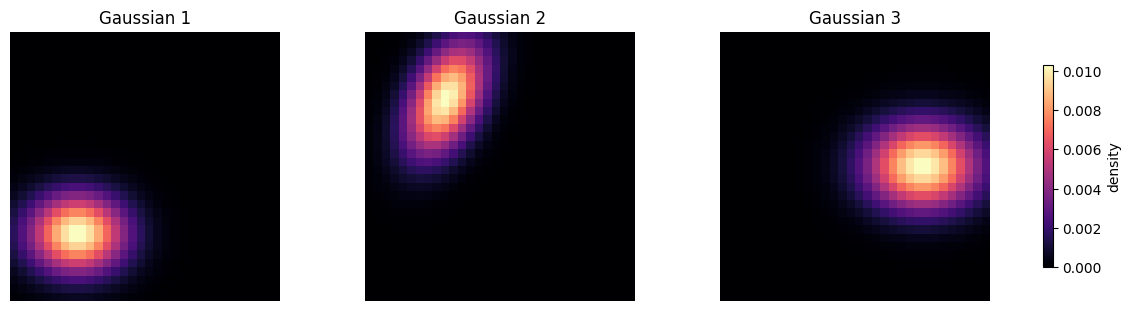

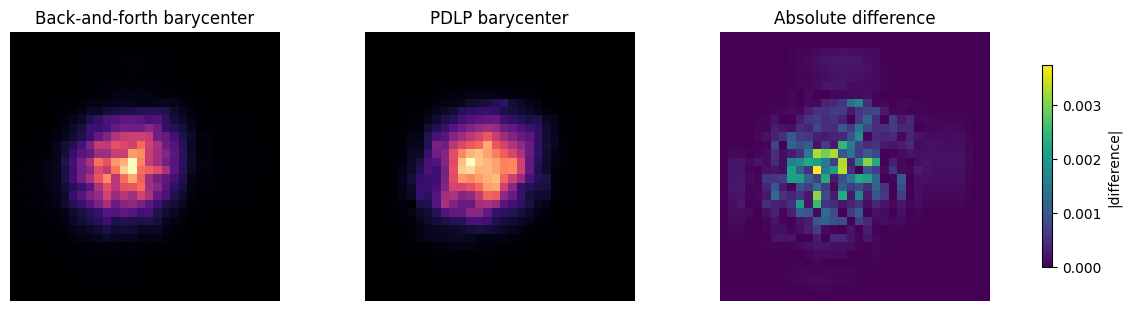

In [6]:
fig, axarr = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
titles = list(shape_fields.keys())
fields = list(shape_fields.values())
for ax, title, field in zip(axarr, titles, fields):
    im = ax.imshow(field, origin='lower', cmap='magma')
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axarr.tolist(), shrink=0.75, label='density')

diff = np.abs(bf_barycenter - pdlp_barycenter)

fig, axarr = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
axarr[0].imshow(bf_barycenter, origin='lower', cmap='magma')
axarr[0].set_title('Back-and-forth barycenter')
axarr[0].axis('off')

axarr[1].imshow(pdlp_barycenter, origin='lower', cmap='magma')
axarr[1].set_title('PDLP barycenter')
axarr[1].axis('off')

im = axarr[2].imshow(diff, origin='lower', cmap='viridis')
axarr[2].set_title('Absolute difference')
axarr[2].axis('off')
fig.colorbar(im, ax=axarr.tolist(), shrink=0.75, label='|difference|')


## Benchmark: 30 Gaussian instances

We sample 30 random Gaussian triples and compare back-and-forth, PDLP, and Sinkhorn barycenters.
Sinkhorn with entropic regularization is used as a proxy ground truth.
Lower `bench_grid_size` or `n_instances` if this is too slow on your machine.


In [ ]:
import time
import contextlib
import io

bench_grid_size = 24
bench_axes = get_axes(dim=2, borders=(0.0, 1.0), n_points=bench_grid_size, cell_discretization='cell-centered')
bench_X, bench_Y = np.meshgrid(bench_axes[0], bench_axes[1], indexing='ij')
bench_points = np.stack([bench_X.reshape(-1), bench_Y.reshape(-1)], axis=1)
bench_cost_matrix = cost_euclid_squared(bench_points, bench_points)
bench_cost_matrix_jax = jnp.asarray(bench_cost_matrix)

n_instances = 30
n_gaussians = 3
weights = np.ones(n_gaussians, dtype=np.float64) / n_gaussians

sinkhorn_eps = 0.03
sinkhorn_maxiter = 300
sinkhorn_tol = 1e-6
sinkhorn_K = np.exp(-bench_cost_matrix / sinkhorn_eps)

axes_jax_bench = [jnp.asarray(ax) for ax in bench_axes]

@contextlib.contextmanager
def suppress_stdout():
    with contextlib.redirect_stdout(io.StringIO()):
        yield


In [ ]:
def sample_gaussian_params(rng):
    mean = rng.uniform(0.2, 0.8, size=2)
    var_x = rng.uniform(0.005, 0.02)
    var_y = rng.uniform(0.005, 0.02)
    rho = rng.uniform(-0.3, 0.3)
    cov_xy = rho * np.sqrt(var_x * var_y)
    cov = np.array([[var_x, cov_xy], [cov_xy, var_y]], dtype=np.float64)
    return mean, cov

def build_gaussian_fields(rng, X, Y, count):
    fields = []
    params = []
    for _ in range(count):
        mean, cov = sample_gaussian_params(rng)
        field = gaussian_2d(X, Y, mean, cov)
        fields.append(normalize_field(field))
        params.append((mean, cov))
    return fields, params

def sinkhorn_barycenter_from_K(K, marginals, weights, maxiter=200, tol=1e-6, eps=1e-16):
    n = K.shape[0]
    m = len(marginals)
    v = [np.ones(n, dtype=np.float64) for _ in range(m)]
    a = np.ones(n, dtype=np.float64) / n
    for _ in range(maxiter):
        u = [a / (K @ v_i + eps) for v_i in v]
        v = [b / (K.T @ u_i + eps) for b, u_i in zip(marginals, u)]
        log_a = np.zeros(n, dtype=np.float64)
        for w, v_i in zip(weights, v):
            log_a += w * np.log(K @ v_i + eps)
        a_new = np.exp(log_a)
        a_new = a_new / a_new.sum()
        if np.linalg.norm(a_new - a, 1) < tol:
            a = a_new
            break
        a = a_new
    return a

def l1_distance(a, b):
    return float(np.sum(np.abs(a - b)))

def l2_distance(a, b):
    return float(np.linalg.norm(a - b))


In [ ]:
rng = np.random.default_rng(0)
warm_fields, _ = build_gaussian_fields(rng, bench_X, bench_Y, n_gaussians)
warm_measures = [jnp.asarray(f) for f in warm_fields]

with suppress_stdout():
    _ = backnforth_barycenter_sqeuclidean_nd(
        weights=weights.tolist(),
        measures_weights=warm_measures,
        coordinates=axes_jax_bench,
        outer_maxiter=2,
        stopping_tol=5e-4,
        relaxation=1.0,
        transport_stepsize=1.0,
        transport_maxiter=200,
        transport_tol=1e-4,
    )

warm_marginals = [
    PointCloudMeasure(bench_points, warm_fields[i].reshape(-1), name=f'warm_{i}')
    for i in range(n_gaussians)
]
warm_solver = PDLPBarycenterSolver()
_ = warm_solver.solve(
    marginals=warm_marginals,
    costs=[bench_cost_matrix_jax],
    weights=jnp.asarray(weights),
    reg=1e-3,
    maxiter=200,
    tol=1e-6,
)

_ = sinkhorn_barycenter_from_K(
    sinkhorn_K,
    [f.reshape(-1) for f in warm_fields],
    weights,
    maxiter=50,
    tol=1e-6,
)


In [ ]:
rng = np.random.default_rng(1)
records = []
solver = PDLPBarycenterSolver()

for idx in range(n_instances):
    fields, _ = build_gaussian_fields(rng, bench_X, bench_Y, n_gaussians)

    measures_weights = [jnp.asarray(f) for f in fields]
    with suppress_stdout():
        t0 = time.perf_counter()
        bf_barycenter, bf_diag = backnforth_barycenter_sqeuclidean_nd(
            weights=weights.tolist(),
            measures_weights=measures_weights,
            coordinates=axes_jax_bench,
            outer_maxiter=8,
            stopping_tol=5e-4,
            relaxation=1.0,
            transport_stepsize=1.0,
            transport_maxiter=300,
            transport_tol=1e-4,
        )
        bf_time = time.perf_counter() - t0
    bf_barycenter = np.asarray(bf_barycenter)

    marginals = [
        PointCloudMeasure(bench_points, fields[i].reshape(-1), name=f'gaussian_{i}')
        for i in range(n_gaussians)
    ]
    t0 = time.perf_counter()
    result = solver.solve(
        marginals=marginals,
        costs=[bench_cost_matrix_jax],
        weights=jnp.asarray(weights),
        reg=1e-3,
        maxiter=1000,
        tol=1e-6,
    )
    pdlp_time = time.perf_counter() - t0
    pdlp_barycenter = np.asarray(result['barycenter']).reshape(bench_grid_size, bench_grid_size)

    t0 = time.perf_counter()
    sinkhorn_barycenter = sinkhorn_barycenter_from_K(
        sinkhorn_K,
        [f.reshape(-1) for f in fields],
        weights,
        maxiter=sinkhorn_maxiter,
        tol=sinkhorn_tol,
    )
    sink_time = time.perf_counter() - t0
    sinkhorn_barycenter = sinkhorn_barycenter.reshape(bench_grid_size, bench_grid_size)

    records.append({
        'bf_time': bf_time,
        'pdlp_time': pdlp_time,
        'sink_time': sink_time,
        'bf_l1': l1_distance(bf_barycenter, sinkhorn_barycenter),
        'pdlp_l1': l1_distance(pdlp_barycenter, sinkhorn_barycenter),
        'bf_l2': l2_distance(bf_barycenter, sinkhorn_barycenter),
        'pdlp_l2': l2_distance(pdlp_barycenter, sinkhorn_barycenter),
    })

    if (idx + 1) % 5 == 0:
        print(f'completed {idx + 1}/{n_instances}')


In [ ]:
def summarize(values):
    values = np.asarray(values, dtype=np.float64)
    return {
        'mean': float(values.mean()),
        'std': float(values.std()),
        'median': float(np.median(values)),
        'min': float(values.min()),
        'max': float(values.max()),
    }

stats = {
    'bf_time': summarize([r['bf_time'] for r in records]),
    'pdlp_time': summarize([r['pdlp_time'] for r in records]),
    'sink_time': summarize([r['sink_time'] for r in records]),
    'bf_l1': summarize([r['bf_l1'] for r in records]),
    'pdlp_l1': summarize([r['pdlp_l1'] for r in records]),
    'bf_l2': summarize([r['bf_l2'] for r in records]),
    'pdlp_l2': summarize([r['pdlp_l2'] for r in records]),
}

for key, s in stats.items():
    print(
        f"{key}: mean={s['mean']:.4e}, std={s['std']:.4e}, median={s['median']:.4e}, min={s['min']:.4e}, max={s['max']:.4e}"
    )
